# 拓樸連結資料集生成

從稀疏標註和 GT 生成神經纖維拓樸連結的訓練資料集。

**輸入**:
- `image.png`: 原始顯微鏡圖像
- `annotation.png`: 稀疏的人工標註
- `label.png`: 完整的 GT mask

**輸出**:
- `dataset_{IMAGE_ID}.csv`: 包含種子座標、成本、標籤等
- `dataset_{IMAGE_ID}_paths.pkl`: 完整路徑座標

**正樣本標準**:
- 端點屬於同一連通分量（在 GT 中）
- 路徑 80% 在 GT mask 中

**負樣本策略**:
- Hard negative mining（距離近但不應連接的種子對）

## 1. 環境設置與導入

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
from scipy.ndimage import label as scipy_label
from scipy.spatial import KDTree
import skimage as ski
from PIL import Image
import cv2
from skimage.filters import sato
from skan import Skeleton, summarize
from skan.csr import skeleton_to_nx
from skimage import morphology
from skimage.measure import label, regionprops
import networkx as nx
import pandas as pd
import pickle
from pathlib import Path

## 2. 配置參數

In [105]:
# 數據集配置
IMAGE_ID = 'S1585-2_a'
BASE_PATH = f"../data/{IMAGE_ID}/"

# 算法參數
SEGMENT_LENGTH = 3          # 種子間距（像素）
SEARCH_RADIUS = 50          # A* 搜索半徑（像素）
GT_COVERAGE_THRESHOLD = 0.5 # 正樣本路徑覆蓋率閾值
PATH_FINDING_BBOX_PADDING = 10  # A* bbox padding

# 輸出配置
OUTPUT_DIR = Path('../data/datasets')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"處理數據集: {IMAGE_ID}")
print(f"配置: segment_length={SEGMENT_LENGTH}, search_radius={SEARCH_RADIUS}")
print(f"輸出目錄: {OUTPUT_DIR}")

處理數據集: S1585-2_a
配置: segment_length=3, search_radius=50
輸出目錄: ../data/datasets


## 3. 數據加載

Original Image Size: (2867, 5632)
Annotation Image Size: (2867, 5632)
GT Label Size: (2867, 5632)


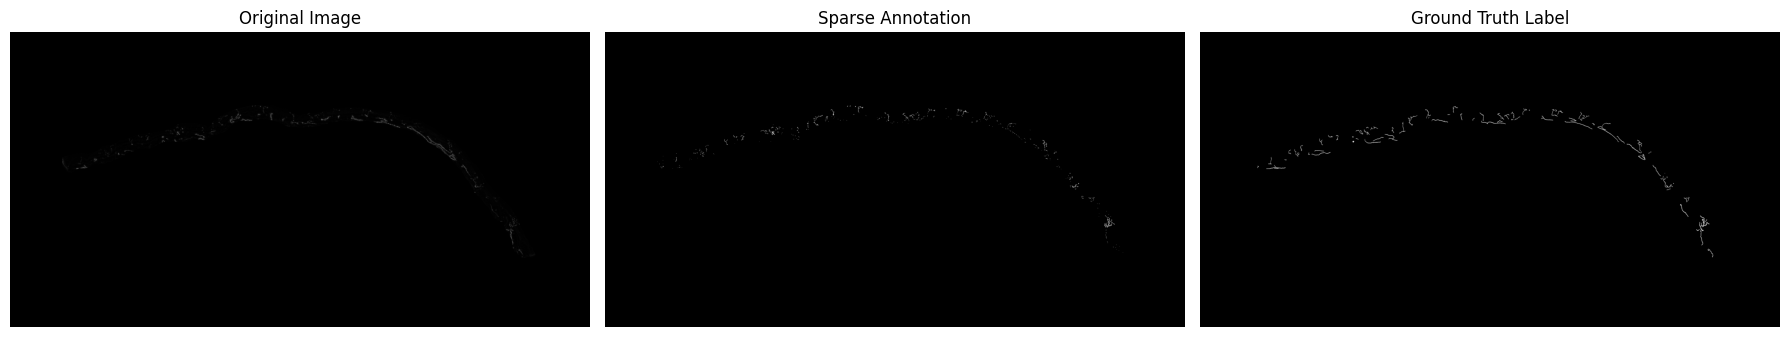

In [106]:
# Load images
orig_img = cv2.imread(f"{BASE_PATH}/roi_image.png", cv2.IMREAD_GRAYSCALE)
mask_img = cv2.imread(f"{BASE_PATH}/mask.png", cv2.IMREAD_GRAYSCALE)
annotation_img = cv2.imread(f"{BASE_PATH}/roi_annotation.png", cv2.IMREAD_GRAYSCALE)
label_img = cv2.imread(f"{BASE_PATH}/label.png", cv2.IMREAD_GRAYSCALE)

print(f"Original Image Size: {orig_img.shape if orig_img is not None else 'Failed to load'}")
print(f"Annotation Image Size: {annotation_img.shape if annotation_img is not None else 'Failed to load'}")
print(f"GT Label Size: {label_img.shape if label_img is not None else 'Failed to load'}")

# Visualize data
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(annotation_img, cmap='gray')
axes[1].set_title('Sparse Annotation')
axes[1].axis('off')

axes[2].imshow(label_img, cmap='gray')
axes[2].set_title('Ground Truth Label')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. 圖像預處理（CLAHE）

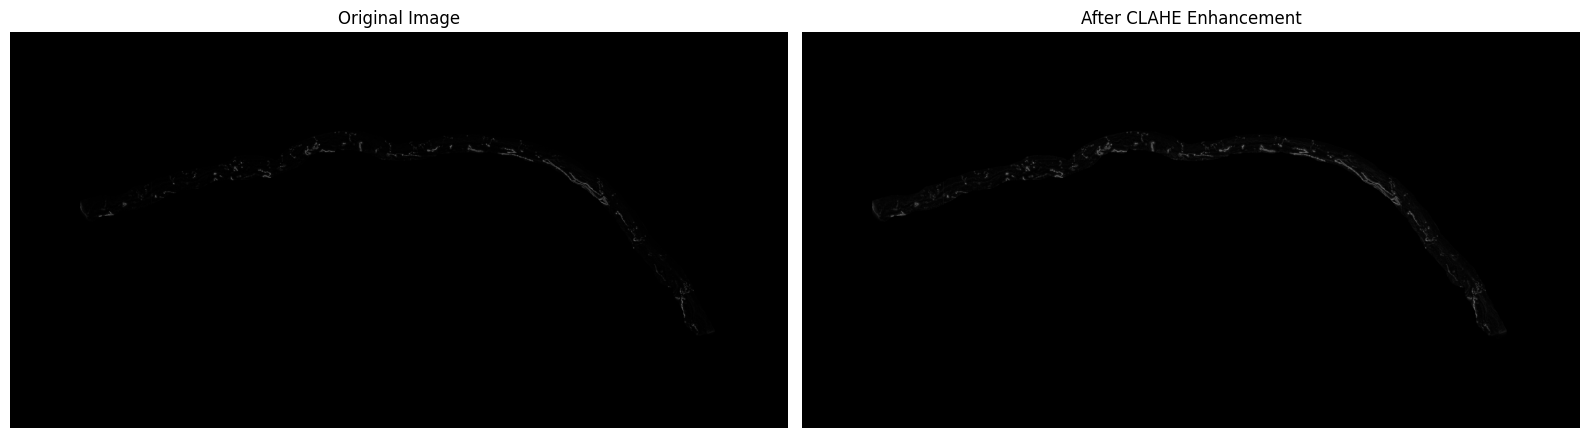

In [107]:
# Ensure image loaded successfully
if orig_img is None:
	raise ValueError("Failed to load original image")

# Use CLAHE to enhance contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
equalized_img = clahe.apply(orig_img)

# Compare original and equalized images
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(equalized_img, cmap='gray')
axes[1].set_title('After CLAHE Enhancement')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. 骨架與種子提取

參考 hierarchical_fragment_linking.ipynb 的實現

In [108]:
# 5.1 骨架化
binary = (annotation_img > 0).astype(np.uint8)
skeleton = morphology.skeletonize(binary).astype(np.uint8)
skel_obj = Skeleton(skeleton, keep_images=False)
summary = summarize(skel_obj)
skeleton_graph = skeleton_to_nx(skel_obj, summary=summary)

print(f"骨架圖節點數: {skeleton_graph.number_of_nodes()}")
print(f"骨架圖邊數: {skeleton_graph.number_of_edges()}")

骨架圖節點數: 860
骨架圖邊數: 459


/tmp/ipykernel_239799/3638323151.py:5: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [109]:
# 5.2 過濾短邊
filtered_skeleton_graph = nx.MultiGraph()
for u, v, data in skeleton_graph.edges(data=True):
    path = data['path']
    if len(path) > 2 or (skeleton_graph.degree(u) != 1 and skeleton_graph.degree(v) != 1):
        filtered_skeleton_graph.add_edge(u, v, **data)

# 將節點 id 轉回座標
mapping = {i: tuple(skel_obj.coordinates[i].astype(int)) for i in filtered_skeleton_graph.nodes()}
filtered_skeleton_graph = nx.relabel_nodes(filtered_skeleton_graph, mapping)

print(f"過濾後節點數: {filtered_skeleton_graph.number_of_nodes()}")
print(f"過濾後邊數: {filtered_skeleton_graph.number_of_edges()}")

過濾後節點數: 508
過濾後邊數: 278


In [110]:
# 5.3 合併中間點
middle_points = [point for point in filtered_skeleton_graph.nodes() if len(list(filtered_skeleton_graph.neighbors(point))) == 2]

for mp in middle_points:
    neighbors = list(filtered_skeleton_graph.neighbors(mp))
    u, v = neighbors
    path1 = filtered_skeleton_graph[u][mp][0]['path']
    path2 = filtered_skeleton_graph[mp][v][0]['path']
    u_y, u_x = u
    mp_y, mp_x = mp
    v_y, v_x = v

    result_path = []
    if tuple(path1[-1]) == (mp_y, mp_x) and tuple(path1[0]) == (u_y, u_x):
        result_path.extend(path1)
    else:
        result_path.extend(path1[::-1])
    
    if tuple(path2[0]) == (mp_y, mp_x) and tuple(path2[-1]) == (v_y, v_x):
        result_path.extend(path2[1:])
    else:
        result_path.extend(path2[-2::-1])
    
    filtered_skeleton_graph.remove_node(mp)
    filtered_skeleton_graph.add_edge(u, v, path=result_path)

print(f"合併中間點後節點數: {filtered_skeleton_graph.number_of_nodes()}")
print(f"合併中間點後邊數: {filtered_skeleton_graph.number_of_edges()}")

合併中間點後節點數: 493
合併中間點後邊數: 256


In [111]:
# 5.4 補齊缺失的節點
label_img_components = label(binary, connectivity=2)
regions = regionprops(label_img_components)

for region in regions:
    min_row, min_col, max_row, max_col = region.bbox
    bbox_nodes = [node for node in filtered_skeleton_graph.nodes() 
                  if node[0] >= min_row and node[0] < max_row and node[1] >= min_col and node[1] < max_col]
    if len(bbox_nodes) != 0:
        continue
    
    brightest_pixel = None
    brightest_value = -1
    
    for r in range(min_row, max_row):
        for c in range(min_col, max_col):
            if equalized_img[r, c] > brightest_value:
                brightest_value = equalized_img[r, c]
                brightest_pixel = (r, c)

    filtered_skeleton_graph.add_node(brightest_pixel)

print(f"補齊節點後總節點數: {filtered_skeleton_graph.number_of_nodes()}")

補齊節點後總節點數: 849


In [112]:
# 5.5 生成種子圖
seed_graph = nx.MultiGraph()
segment_length = SEGMENT_LENGTH

for u in filtered_skeleton_graph.nodes():
    seed_graph.add_node(u)

for u, v, data in filtered_skeleton_graph.edges(data=True):
    path = data['path']
    # 擺正方向
    corrected_path = path[:] if tuple(path[0]) == u and tuple(path[-1]) == v else path[::-1]
    path_arr = np.array(corrected_path)
    diffs = np.diff(path_arr, axis=0)
    distances = np.linalg.norm(diffs, axis=1)
    cumulative_distances = np.concatenate(([0], np.cumsum(distances)))
    path_length = cumulative_distances[-1]
    num_segments = int(path_length // segment_length)
    
    if num_segments <= 0:
        seed_graph.add_edge(u, v, path=path)
        continue
    
    last_index = 0
    for i in range(num_segments):
        target_distance = (i + 1) * path_length / num_segments
        segment_end_index = 0
        for idx, cumulative_distance in enumerate(cumulative_distances[last_index:]):
            if cumulative_distance >= target_distance:
                segment_end_index = idx + last_index
                break
        segment_path = corrected_path[last_index:segment_end_index + 1]
        if len(segment_path) == 0:
            continue
        seed_graph.add_edge(tuple(segment_path[0]), tuple(segment_path[-1]), path=segment_path)
        last_index = segment_end_index
    
    if last_index < len(corrected_path) - 1:
        final_segment_path = corrected_path[last_index:]
        seed_graph.add_edge(tuple(final_segment_path[0]), tuple(final_segment_path[-1]), path=final_segment_path)

print(f"種子圖節點數（種子點）: {seed_graph.number_of_nodes()}")
print(f"種子圖邊數: {seed_graph.number_of_edges()}")

種子圖節點數（種子點）: 1086
種子圖邊數: 493


In [113]:
# 可視化種子圖
viz_img = cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)
viz_img = cv2.addWeighted(viz_img, 0.7, cv2.cvtColor(label_img, cv2.COLOR_GRAY2BGR), 0.3, 0)

for u, v, data in seed_graph.edges(data=True):
    path = data['path']
    for y_i, x_i in path:
        viz_img[y_i, x_i] = [0, 255, 0]

for u in seed_graph.nodes():
    viz_img[u] = [255, 0, 0]

plt.figure(figsize=(128, 128))
plt.imshow(viz_img)
plt.title('seed map (green=paths, blue=seed points)')
plt.axis('off')
plt.show()

## 6. GT 連通分量標記

In [114]:
# 對 GT label.png 進行連通分量分析
dilate_label_img = morphology.dilation(label_img > 0, morphology.disk(1))
gt_label_components, num_components = scipy_label(dilate_label_img > 0, structure=np.ones((3,3)))
print(f"GT 中有 {num_components} 個連通分量")

# 可視化連通分量
plt.figure(figsize=(128, 128))
plt.imshow(gt_label_components, cmap='nipy_spectral')
plt.title(f'GT 連通分量（共 {num_components} 個）')
plt.axis('off')
plt.show()

GT 中有 76 個連通分量


/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36899 (\N{CJK UNIFIED IDEOGRAPH-9023}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py

## 7. A* 路徑查找與標註生成

In [115]:
# 7.1 正負樣本判斷函數
def is_positive_sample(seed1, seed2, path, gt_label_components, label_img, threshold=0.8):
    """
    判斷是否為正樣本
    
    條件：
    1. seed1 和 seed2 在 GT 中屬於同一連通分量
    2. 路徑上 >= threshold 的像素在 GT mask 中
    """
    # 條件1: 檢查連通性
    comp1 = gt_label_components[seed1[0], seed1[1]]
    comp2 = gt_label_components[seed2[0], seed2[1]]
    
    if comp1 == 0 or comp2 == 0 or comp1 != comp2:
        return False
    
    # 條件2: 檢查路徑覆蓋率
    path_pixels_in_gt = sum(1 for p in path if label_img[p[0], p[1]] > 0)
    coverage = path_pixels_in_gt / len(path)
    
    return coverage >= threshold

print("正負樣本判斷函數已定義")

正負樣本判斷函數已定義


In [116]:
# 7.2 建立 KDTree 和成本地圖
topology_points = np.array(list(seed_graph.nodes()))
kdtree = KDTree(topology_points)

# 建立成本地圖
cost_map = ((255 - equalized_img.astype(np.float64)) / 255.0) ** 8
cost_map_h, cost_map_w = cost_map.shape

# 建立種子地圖（用於過濾路徑）
seed_map = np.zeros_like(cost_map, dtype=np.uint8)
for p in topology_points:
    seed_map[p[0], p[1]] = True

print(f"種子點數: {len(topology_points)}")
print(f"成本地圖尺寸: {cost_map.shape}")

種子點數: 1086
成本地圖尺寸: (2867, 5632)


In [117]:
# 7.3 A* 路徑查找與樣本收集
all_samples = []  # 存儲所有樣本信息
sample_id = 0

# 獲取 annotation 的連通分量（用於排除同一 component 的點）
annotation_components = label(binary, connectivity=2)

for u_idx in range(len(topology_points)):
    search_radius = SEARCH_RADIUS
    u = topology_points[u_idx]
    
    # 查詢半徑內的所有鄰居
    neighbor_indices = kdtree.query_ball_point(u, r=search_radius)
    targets = [topology_points[v_idx] for v_idx in neighbor_indices]
    
    # 排除自己
    targets = [target for target in targets if tuple(target) != tuple(u)]
    
    # 排除屬於同一個 annotation component 的點
    current_component_id = annotation_components[u[0], u[1]]
    targets = [target for target in targets 
               if annotation_components[target[0], target[1]] != current_component_id]
    
    if len(targets) == 0:
        continue
    
    # 計算包含所有點的最小 bbox + padding
    all_points = [u] + targets
    all_y = [p[0] for p in all_points]
    all_x = [p[1] for p in all_points]
    
    min_y = max(0, min(all_y) - PATH_FINDING_BBOX_PADDING)
    max_y = min(cost_map_h - 1, max(all_y) + PATH_FINDING_BBOX_PADDING)
    min_x = max(0, min(all_x) - PATH_FINDING_BBOX_PADDING)
    max_x = min(cost_map_w - 1, max(all_x) + PATH_FINDING_BBOX_PADDING)
    
    cropped_cost_map = cost_map[min_y : max_y + 1, min_x : max_x + 1]
    
    local_points = [(pos_global[0] - min_y, pos_global[1] - min_x) for pos_global in all_points]
    mcp = ski.graph.MCP_Geometric(cropped_cost_map, fully_connected=True)
    cumulative_costs, traceback = mcp.find_costs(starts=local_points[:1], ends=local_points[1:])
    
    for target in local_points[1:]:
        if np.isinf(cumulative_costs[target]):
            continue
        
        path = mcp.traceback(target)
        cost = cumulative_costs[target]
        
        # 轉換回全局座標
        global_path = [(p[0] + min_y, p[1] + min_x) for p in path]
        global_start = (u[0], u[1])
        global_target = (target[0] + min_y, target[1] + min_x)
        
        # 過濾路徑中經過其他種子的連接
        middle_points = np.array(path[1:-1])
        if len(middle_points) > 0:
            # 轉換為全局座標檢查
            middle_points_global = middle_points + np.array([min_y, min_x])
            if np.any(seed_map[middle_points_global[:, 0], middle_points_global[:, 1]]):
                continue
        
        # 計算距離和路徑長度
        distance = np.linalg.norm(np.array(global_start) - np.array(global_target))
        path_length = len(global_path)
        normalized_cost = cost / path_length if path_length > 0 else cost
        
        # 判斷正負樣本
        label_value = 1 if is_positive_sample(
            global_start, global_target, global_path, 
            gt_label_components, label_img, GT_COVERAGE_THRESHOLD
        ) else 0
        
        # 保存樣本信息
        all_samples.append({
            'sample_id': sample_id,
            'image_id': IMAGE_ID,
            'seed1_y': global_start[0],
            'seed1_x': global_start[1],
            'seed2_y': global_target[0],
            'seed2_x': global_target[1],
            'distance': distance,
            'path_length': path_length,
            'path_cost': cost,
            'normalized_cost': normalized_cost,
            'label': label_value,
            'path': global_path
        })
        sample_id += 1
    
    # 每處理 100 個種子點打印進度
    if (u_idx + 1) % 100 == 0:
        print(f"已處理 {u_idx + 1}/{len(topology_points)} 個種子點，收集 {len(all_samples)} 個樣本")

print(f"\n總共收集 {len(all_samples)} 個樣本")

已處理 100/1086 個種子點，收集 397 個樣本
已處理 200/1086 個種子點，收集 814 個樣本
已處理 300/1086 個種子點，收集 1457 個樣本
已處理 400/1086 個種子點，收集 1934 個樣本
已處理 500/1086 個種子點，收集 2519 個樣本
已處理 600/1086 個種子點，收集 3162 個樣本
已處理 700/1086 個種子點，收集 3818 個樣本
已處理 800/1086 個種子點，收集 4428 個樣本
已處理 900/1086 個種子點，收集 4914 個樣本
已處理 1000/1086 個種子點，收集 5364 個樣本

總共收集 5700 個樣本


In [118]:
# 統計正負樣本數量
positive_samples = [s for s in all_samples if s['label'] == 1]
negative_samples = [s for s in all_samples if s['label'] == 0]

print(f"正樣本數: {len(positive_samples)}")
print(f"負樣本數: {len(negative_samples)}")
print(f"正負比例: {len(positive_samples)}/{len(negative_samples)} = {len(positive_samples)/len(negative_samples):.2f}")

正樣本數: 1790
負樣本數: 3910
正負比例: 1790/3910 = 0.46


## 8. Hard Negative 採樣

In [119]:
# 8.1 按距離排序負樣本（距離越近越困難）
negative_samples_sorted = sorted(negative_samples, key=lambda x: x['distance'])

# 8.2 選擇 hard negatives（數量與正樣本相同）
num_positives = len(positive_samples)
num_hard_negatives = min(num_positives, len(negative_samples_sorted))
hard_negatives = negative_samples_sorted[:num_hard_negatives]

print(f"選擇 {num_hard_negatives} 個 hard negative 樣本")
print(f"Hard negative 距離範圍: {hard_negatives[0]['distance']:.2f} ~ {hard_negatives[-1]['distance']:.2f}")

# 8.3 合併最終數據集
final_samples = positive_samples + hard_negatives
print(f"\n最終數據集: {len(final_samples)} 個樣本")
print(f"  正樣本: {len(positive_samples)}")
print(f"  負樣本 (hard): {len(hard_negatives)}")

選擇 1790 個 hard negative 樣本
Hard negative 距離範圍: 2.83 ~ 22.02

最終數據集: 3580 個樣本
  正樣本: 1790
  負樣本 (hard): 1790


## 9. 數據集保存

In [120]:
# 9.1 準備 CSV 數據（不包含 path）
csv_data = [{k: v for k, v in sample.items() if k != 'path'} for sample in final_samples]
df = pd.DataFrame(csv_data)

# 保存 CSV
csv_path = OUTPUT_DIR / f"dataset_{IMAGE_ID}.csv"
df.to_csv(csv_path, index=False)
print(f"✓ CSV 已保存: {csv_path}")
print(f"  欄位: {list(df.columns)}")

# 顯示前幾行
print("\n前 5 個樣本:")
display(df.head())

✓ CSV 已保存: ../data/datasets/dataset_S1585-2_a.csv
  欄位: ['sample_id', 'image_id', 'seed1_y', 'seed1_x', 'seed2_y', 'seed2_x', 'distance', 'path_length', 'path_cost', 'normalized_cost', 'label']

前 5 個樣本:


,sample_id,image_id,seed1_y,seed1_x,seed2_y,seed2_x,distance,path_length,path_cost,normalized_cost,label
0,14,S1585-2_a,735,2478,732,2471,7.615773,8,2.690013,0.336252,1
1,19,S1585-2_a,740,2490,740,2500,10.000000,12,2.727683,0.227307,1
2,25,S1585-2_a,740,2460,732,2465,9.433981,10,4.275653,0.427565,1
3,30,S1585-2_a,746,2458,750,2465,8.062258,9,2.421011,0.269001,1
4,31,S1585-2_a,746,2458,751,2461,5.830952,6,1.981034,0.330172,1


In [121]:
# 9.2 保存路徑信息（pickle）
paths_dict = {sample['sample_id']: sample['path'] for sample in final_samples}
pickle_path = OUTPUT_DIR / f"dataset_{IMAGE_ID}_paths.pkl"

with open(pickle_path, 'wb') as f:
    pickle.dump(paths_dict, f)

print(f"✓ 路徑信息已保存: {pickle_path}")
print(f"  包含 {len(paths_dict)} 條路徑")

✓ 路徑信息已保存: ../data/datasets/dataset_S1585-2_a_paths.pkl
  包含 3580 條路徑


## 10. 統計分析與可視化

In [122]:
# 10.1 統計分析
print("="*60)
print("數據集統計信息")
print("="*60)

# 正負樣本統計
print(f"\n樣本數量:")
print(df['label'].value_counts())

# 距離統計
print(f"\n距離統計:")
print(df.groupby('label')['distance'].describe())

# 成本統計
print(f"\n歸一化成本統計:")
print(df.groupby('label')['normalized_cost'].describe())

# 路徑長度統計
print(f"\n路徑長度統計:")
print(df.groupby('label')['path_length'].describe())

數據集統計信息

樣本數量:
label
1    1790
0    1790
Name: count, dtype: int64

距離統計:
        count       mean       std       min       25%        50%        75%  \
label                                                                          
0      1790.0  13.767939  4.900605  2.828427  9.899495  13.892444  18.027756   
1      1790.0  13.766465  8.125902  2.000000  8.000000  11.401754  17.691806   

             max  
label             
0      22.022716  
1      49.040799  

歸一化成本統計:
        count      mean       std       min       25%       50%       75%  \
label                                                                       
0      1790.0  0.422470  0.193402  0.008173  0.287213  0.426394  0.577591   
1      1790.0  0.342887  0.169534  0.003886  0.239958  0.360434  0.466909   

            max  
label            
0      0.950099  
1      0.819061  

路徑長度統計:
        count       mean       std  min   25%   50%   75%   max
label                                                          
0

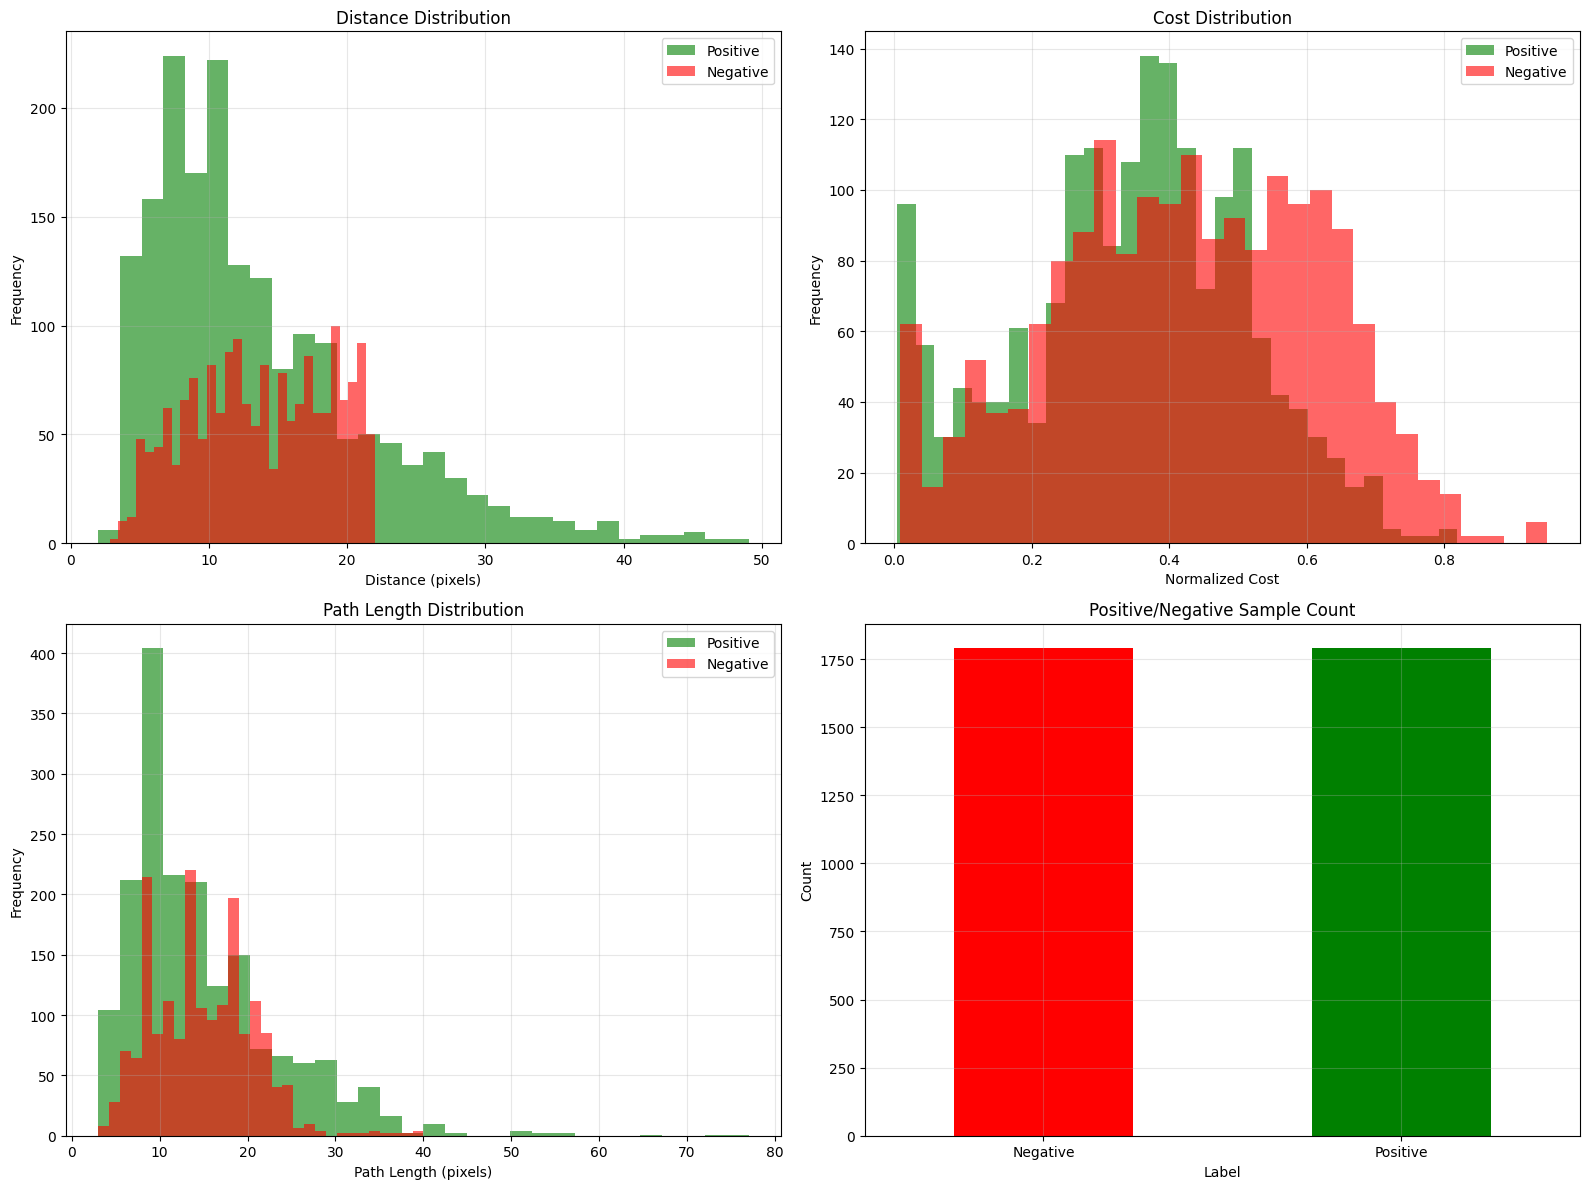

In [123]:
# 10.2 Distribution Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distance distribution
ax = axes[0, 0]
df[df['label'] == 1]['distance'].hist(bins=30, alpha=0.6, label='Positive', ax=ax, color='green')
df[df['label'] == 0]['distance'].hist(bins=30, alpha=0.6, label='Negative', ax=ax, color='red')
ax.set_xlabel('Distance (pixels)')
ax.set_ylabel('Frequency')
ax.set_title('Distance Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Cost distribution
ax = axes[0, 1]
df[df['label'] == 1]['normalized_cost'].hist(bins=30, alpha=0.6, label='Positive', ax=ax, color='green')
df[df['label'] == 0]['normalized_cost'].hist(bins=30, alpha=0.6, label='Negative', ax=ax, color='red')
ax.set_xlabel('Normalized Cost')
ax.set_ylabel('Frequency')
ax.set_title('Cost Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Path length distribution
ax = axes[1, 0]
df[df['label'] == 1]['path_length'].hist(bins=30, alpha=0.6, label='Positive', ax=ax, color='green')
df[df['label'] == 0]['path_length'].hist(bins=30, alpha=0.6, label='Negative', ax=ax, color='red')
ax.set_xlabel('Path Length (pixels)')
ax.set_ylabel('Frequency')
ax.set_title('Path Length Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Positive/Negative sample count
ax = axes[1, 1]
df['label'].value_counts().plot(kind='bar', ax=ax, color=['red', 'green'])
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Positive/Negative Sample Count')
ax.set_xticklabels(['Negative', 'Positive'], rotation=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_239799/2927254439.py:81: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/2927254439.py:81: UserWarning: Glyph 27171 (\N{CJK UNIFIED IDEOGRAPH-6A23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/2927254439.py:81: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/2927254439.py:81: UserWarning: Glyph 36000 (\N{CJK UNIFIED IDEOGRAPH-8CA0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27171 (\N{CJK UNIFIED IDEOGRAPH-6A23}) missing 

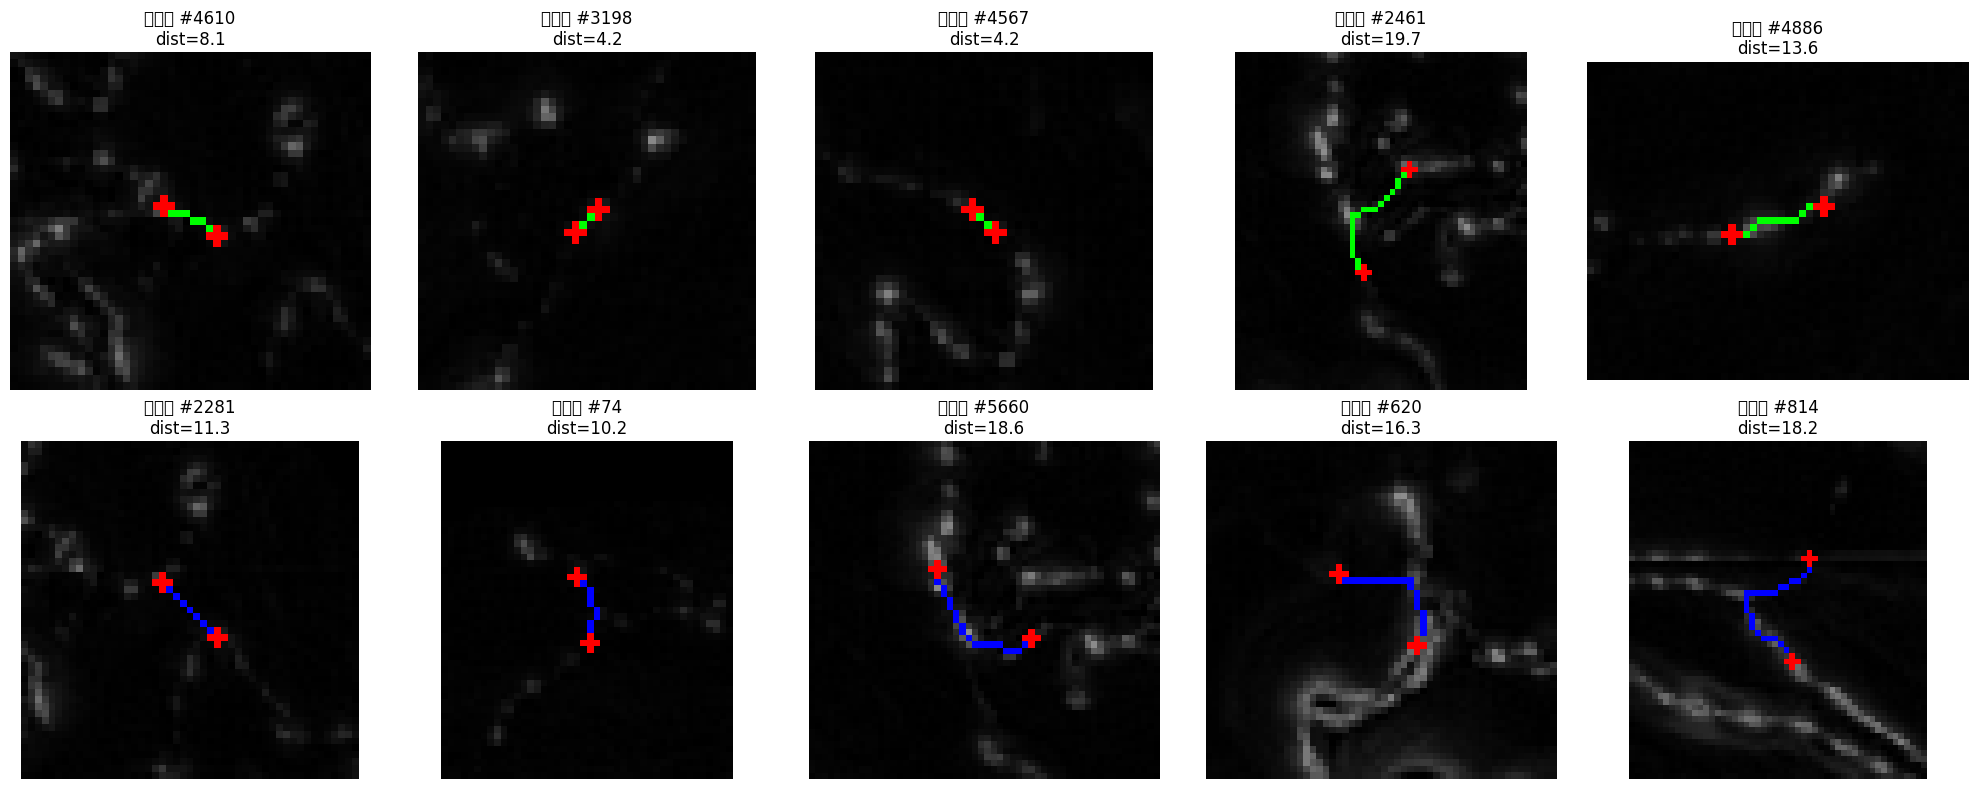

In [124]:
# 10.3 樣本可視化
# 隨機選擇幾個正負樣本進行可視化
num_examples = 5
positive_examples = np.random.choice(len(positive_samples), min(num_examples, len(positive_samples)), replace=False)
negative_examples = np.random.choice(len(hard_negatives), min(num_examples, len(hard_negatives)), replace=False)

fig, axes = plt.subplots(2, num_examples, figsize=(20, 8))

# 繪製正樣本
for idx, sample_idx in enumerate(positive_examples):
    sample = positive_samples[sample_idx]
    ax = axes[0, idx]
    
    # 繪製局部區域
    path = sample['path']
    all_y = [p[0] for p in path] + [sample['seed1_y'], sample['seed2_y']]
    all_x = [p[1] for p in path] + [sample['seed1_x'], sample['seed2_x']]
    
    padding = 20
    min_y = max(0, min(all_y) - padding)
    max_y = min(orig_img.shape[0] - 1, max(all_y) + padding)
    min_x = max(0, min(all_x) - padding)
    max_x = min(orig_img.shape[1] - 1, max(all_x) + padding)
    
    roi = orig_img[min_y:max_y+1, min_x:max_x+1]
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)
    
    # 繪製路徑
    for p in path:
        local_y = p[0] - min_y
        local_x = p[1] - min_x
        if 0 <= local_y < roi_rgb.shape[0] and 0 <= local_x < roi_rgb.shape[1]:
            roi_rgb[local_y, local_x] = [0, 255, 0]
    
    # 繪製端點
    seed1_local = (sample['seed1_y'] - min_y, sample['seed1_x'] - min_x)
    seed2_local = (sample['seed2_y'] - min_y, sample['seed2_x'] - min_x)
    cv2.circle(roi_rgb, (seed1_local[1], seed1_local[0]), 1, (255, 0, 0), -1)
    cv2.circle(roi_rgb, (seed2_local[1], seed2_local[0]), 1, (255, 0, 0), -1)
    
    ax.imshow(roi_rgb)
    ax.set_title(f"正樣本 #{sample['sample_id']}\ndist={sample['distance']:.1f}")
    ax.axis('off')

# 繪製負樣本
for idx, sample_idx in enumerate(negative_examples):
    sample = hard_negatives[sample_idx]
    ax = axes[1, idx]
    
    # 繪製局部區域
    path = sample['path']
    all_y = [p[0] for p in path] + [sample['seed1_y'], sample['seed2_y']]
    all_x = [p[1] for p in path] + [sample['seed1_x'], sample['seed2_x']]
    
    padding = 20
    min_y = max(0, min(all_y) - padding)
    max_y = min(orig_img.shape[0] - 1, max(all_y) + padding)
    min_x = max(0, min(all_x) - padding)
    max_x = min(orig_img.shape[1] - 1, max(all_x) + padding)
    
    roi = orig_img[min_y:max_y+1, min_x:max_x+1]
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)
    
    # 繪製路徑
    for p in path:
        local_y = p[0] - min_y
        local_x = p[1] - min_x
        if 0 <= local_y < roi_rgb.shape[0] and 0 <= local_x < roi_rgb.shape[1]:
            roi_rgb[local_y, local_x] = [0, 0, 255]
    
    # 繪製端點
    seed1_local = (sample['seed1_y'] - min_y, sample['seed1_x'] - min_x)
    seed2_local = (sample['seed2_y'] - min_y, sample['seed2_x'] - min_x)
    cv2.circle(roi_rgb, (seed1_local[1], seed1_local[0]), 1, (255, 0, 0), -1)
    cv2.circle(roi_rgb, (seed2_local[1], seed2_local[0]), 1, (255, 0, 0), -1)
    
    ax.imshow(roi_rgb)
    ax.set_title(f"負樣本 #{sample['sample_id']}\ndist={sample['distance']:.1f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 完成

數據集生成完成！

**輸出文件**:
- `data/datasets/dataset_{IMAGE_ID}.csv`: 樣本特徵和標籤
- `data/datasets/dataset_{IMAGE_ID}_paths.pkl`: 完整路徑座標

**下一步**:
- 可以使用類似的方式處理其他有 label.png 的數據集
- 合併多個數據集以獲得更大的訓練集
- 使用這些數據訓練分類模型

In [125]:
# 在原始图像上绘制所有正样本
viz_positive = cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)

for sample in positive_samples:
	path = sample['path']
	
	# 绘制路径（绿色）
	for p in path:
		y, x = p
		if 0 <= y < viz_positive.shape[0] and 0 <= x < viz_positive.shape[1]:
			viz_positive[y, x] = [0, 255, 0]
	
	# 绘制端点（蓝色）
	seed1_y, seed1_x = sample['seed1_y'], sample['seed1_x']
	seed2_y, seed2_x = sample['seed2_y'], sample['seed2_x']
	
	cv2.circle(viz_positive, (seed1_x, seed1_y), 1, (255, 0, 0), -1)
	cv2.circle(viz_positive, (seed2_x, seed2_y), 1, (255, 0, 0), -1)

# 使用其他颜色显示负样本
for sample in hard_negatives:
	path = sample['path']
	
	# 绘制路径（红色）
	for p in path:
		y, x = p
		if 0 <= y < viz_positive.shape[0] and 0 <= x < viz_positive.shape[1]:
			viz_positive[y, x] = [0, 0, 255]
	
	# 绘制端点（青色）
	seed1_y, seed1_x = sample['seed1_y'], sample['seed1_x']
	seed2_y, seed2_x = sample['seed2_y'], sample['seed2_x']
	
	cv2.circle(viz_positive, (seed1_x, seed1_y), 1, (255, 255, 0), -1)
	cv2.circle(viz_positive, (seed2_x, seed2_y), 1, (255, 255, 0), -1)

plt.figure(figsize=(128, 128))
plt.imshow(viz_positive)
plt.title(f'所有样本路径 (绿色=正样本:{len(positive_samples)}, 红色=负样本:{len(hard_negatives)})')
plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_239799/3585737534.py:41: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/3585737534.py:41: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/3585737534.py:41: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/3585737534.py:41: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/3585737534.py:41: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/3585737534.py:41: UserWarning: Glyph 24452 (\N{CJK UNIFIED IDEOGRAPH-5F84}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239799/3585737534.py:41: UserWarning: Glyph 32511 (\N{CJK UNIFIED I